# Introduction to Leslie Matrix Models 

The Leslie Matrix model is a powerful tool in population ecology developed by Patrick H. Leslie in the 1940s, used to model the growth of populations that are structured by **age classes**. It operates in discrete time steps (e.g., year to year) and uses matrix multiplication to project the future size and age distribution of a population.

Unlike simpler models (like the Logistic Growth Model) that treat populations as homogeneous, the Leslie Matrix explicitly incorporates demographic structure.  It tracks a vector of age-specific population counts, recognizing that reproduction and survival depend heavily on an individual's age.

### Core Components
The model relies on a square matrix $L$ containing two key demographic rates:
* **Fecundity rates ($f_i$):** The average number of offspring produced by individuals in each age class, forming the first row of the matrix.
* **Survival probabilities ($s_i$):** The proportion of individuals surviving from one age class to the next, forming the sub-diagonal.
* All other entries are typically zero.

The core projection equation to find the population vector at the next time step ($t+1$) is:

$N_{t+1} = L \times N_t$

## Example 1: Building a Basic Leslie Matrix

Let's model a hypothetical bird population with three age classes.

**Demographics:**
* Juveniles (Class 1): Do not reproduce ($f_1 = 0$), 50% survival ($s_1 = 0.5$).
* Young Adults (Class 2): 2 offspring/year ($f_2 = 2$), 70% survival ($s_2 = 0.7$).
* Mature Adults (Class 3): 1 offspring/year ($f_3 = 1$), do not survive past year 3.

**Initial Population ($t=0$):** 10 Juveniles, 8 Young Adults, 5 Mature Adults.

In [ ]:
import numpy as np

# 1. Define demographic parameters
f = np.array([0, 2, 1])     # Fecundity rates
s = np.array([0.5, 0.7])    # Survival rates

# 2. Construct the Leslie Matrix L
L = np.zeros((3, 3))
L[0, :] = f                 # First row contains fecundities
L[1, 0] = s[0]              # Sub-diagonal contains survival rates
L[2, 1] = s[1]

print("Leslie Matrix (L):\n", L)

# 3. Define Initial Population Vector N0
N0 = np.array([10, 8, 5])
print("\nInitial Population Vector (N0):\n", N0)

# 4. Project the Population for One Time Step
N1 = L @ N0                 # The @ operator performs matrix multiplication in Python
print("\nPopulation Vector at t=1 (N1):\n", N1)

Leslie Matrix (L):
 [[0.  2.  1. ]
 [0.5 0.  0. ]
 [0.  0.7 0. ]]

Initial Population Vector (N0):
 [10  8  5]

Population Vector at t=1 (N1):
 [21.   5.   5.6]


## Example 2: Simulating Population Growth Over Time

Now, let's look at another bird population scenario to simulate the population for 20 years.
* Chicks (0-1 yr): $F_1 = 0$, $S_1 = 0.6$.
* Young Adults (1-2 yr): $F_2 = 1.5$, $S_2 = 0.5$.
* Older Adults (2-3 yr): $F_3 = 2.0$, $S_3 = 0$.
* Initial population: 100 chicks, 0 adults.

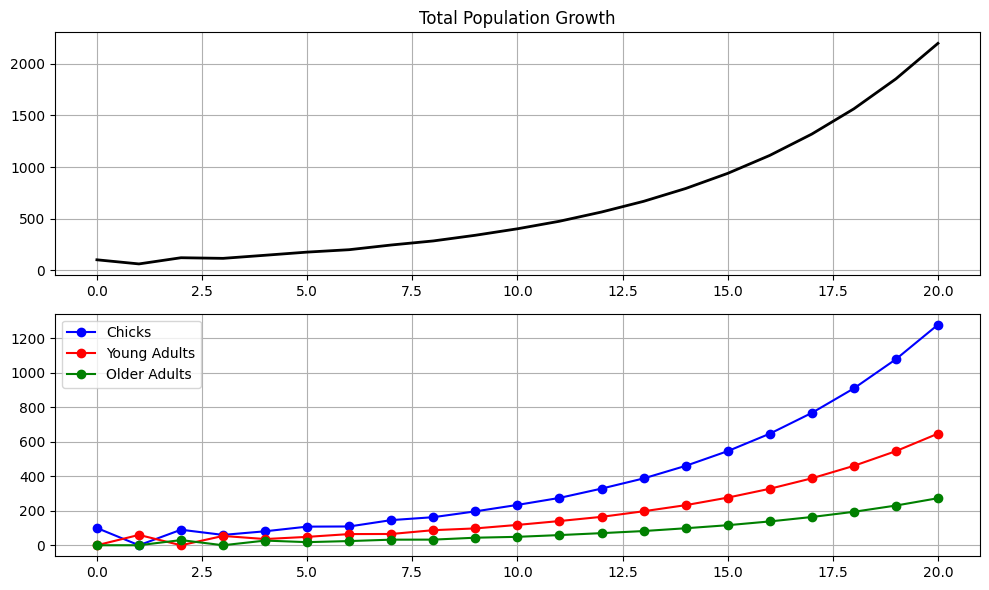

In [ ]:
import matplotlib.pyplot as plt

# Define parameters
F1 = 0;   F2 = 1.5; F3 = 2.0
S1 = 0.6; S2 = 0.5

# Construct Leslie Matrix
L_sim = np.array([[F1, F2, F3],
                  [S1, 0,  0],
                  [0,  S2, 0]])

# Initial population vector
n0 = np.array([100, 0, 0])

# Simulation Loop for 20 years
years = 20
pop_history = np.zeros((3, years + 1))
pop_history[:, 0] = n0

for t in range(years):
    pop_history[:, t+1] = L_sim @ pop_history[:, t]

# Calculate total population
total_pop = np.sum(pop_history, axis=0)
t_arr = np.arange(years + 1)

# Visualizing Results
plt.figure(figsize=(10, 6))

plt.subplot(2,1,1)
plt.plot(t_arr, total_pop, 'k-', linewidth=2)
plt.title('Total Population Growth')
plt.grid(True)

plt.subplot(2,1,2)
plt.plot(t_arr, pop_history[0, :], 'b-o', label='Chicks')
plt.plot(t_arr, pop_history[1, :], 'r-o', label='Young Adults')
plt.plot(t_arr, pop_history[2, :], 'g-o', label='Older Adults')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

## Long-term Dynamics: Stable Age Distribution and Growth Rate ($\lambda$)

If we simulate the population for many time steps, two things happen:
1. **Stable Age Distribution:** The proportion of individuals in each age class becomes constant, regardless of the initial population state.
2. **Population Growth ($\lambda$):** The total population eventually grows (or declines) at a constant finite rate of increase, denoted as $\lambda$.

We can calculate $\lambda$ numerically via our simulation ratio $\lambda \approx N(t+1) / N(t)$, or analytically by finding the dominant eigenvalue of the Leslie Matrix.

In [ ]:
# --- Stable Age Distribution ---
# Normalize to find proportions
proportions = pop_history / np.sum(pop_history, axis=0)

print("Previous Year Distribution (t=19):\n", proportions[:, -2])
print("Final Age Distribution (t=20):\n", proportions[:, -1])
print("\n(The vector values stabilize, confirming the Stable Age Distribution theorem.)")

# --- Calculating Lambda (Growth Rate) ---
# Method A: From Simulation
lambda_sim = total_pop[-1] / total_pop[-2]
print(f"\nSimulated Lambda: {lambda_sim:.4f}")

# Method B: Eigenanalysis using linear algebra
eigenvalues = np.linalg.eigvals(L_sim)
lambda_eig = np.max(np.real(eigenvalues))  # Dominant eigenvalue is the maximum real value
print(f"Theoretical Lambda: {lambda_eig:.4f}")

Previous Year Distribution (t=19):
 [0.58162244 0.29424786 0.1241297 ]
Final Age Distribution (t=20):
 [0.58160965 0.29431142 0.12407893]

(The vector values stabilize, confirming the Stable Age Distribution theorem.)

Simulated Lambda: 1.1857
Theoretical Lambda: 1.1858
